Task 1 - Data Cleaning (Python) - 03-15-2026 - urzraz2644

In [1]:
import  pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_excel("AirBnBSummary_v2.xlsx")
df.head()

,id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
0,7909479,41706311,David,Downtown,Entire home/apt,107.0,30,27,365.0,urzraz2644
1,15966488,103700433,Erin,Downtown,Entire home/apt,100.0,1,250,74.0,urzraz2644
2,19859814,103700433,Erin,Downtown,Entire home/apt,100.0,1,309,79.0,urzraz2644
3,21071138,22992627,Joseph,Downtown,Entire home/apt,100.0,2,144,338.0,urzraz2644
4,21712505,103700433,Erin,Downtown,Entire home/apt,100.0,1,178,68.0,urzraz2644


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1779 entries, 0 to 1778
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 1779 non-null   int64  
 1   host_id            1779 non-null   int64  
 2   host_name          1779 non-null   str    
 3   neighbourhood      1779 non-null   str    
 4   room_type          1779 non-null   str    
 5   price              1775 non-null   float64
 6   minimum_nights     1779 non-null   int64  
 7   number_of_reviews  1779 non-null   int64  
 8   availability_365   1774 non-null   float64
 9   <StudentID>        1779 non-null   str    
dtypes: float64(2), int64(4), str(4)
memory usage: 139.1 KB


In [4]:
df = df.drop_duplicates()
print("Rows after removing duplicates:", df.shape[0])

Rows after removing duplicates: 1775


In [5]:
df['price'] = df['price'].fillna(df['price'].median())
df['availability_365'] = df['availability_365'].fillna(df['availability_365'].median())


In [6]:
df.isnull().sum()


id                   0
host_id              0
host_name            0
neighbourhood        0
room_type            0
price                0
minimum_nights       0
number_of_reviews    0
availability_365     0
<StudentID>          0
dtype: int64

In [7]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

df = df[(df['price'] >= Q1 - 1.5 * IQR) & (df['price'] <= Q3 + 1.5 * IQR)]
print("Rows after removing outliers:", df.shape[0])

Rows after removing outliers: 1657


In [8]:
df.to_excel("AirBnB_Cleaned.xlsx", index=False)
print("Cleaned dataset saved to Excel.")

Cleaned dataset saved to Excel.


## Descriptive Statistics
The following statistics summarize the cleaned Airbnb dataset.

In [9]:
print("Total count of listings:", df.shape[0])
print("Minimum price:", df['price'].min())
print("Maximum price:", df['price'].max())
print("Mean price:", df['price'].mean())
print("Median of number_of_reviews:", df['number_of_reviews'].median())
print("Mode of minimum_nights:", df['minimum_nights'].mode()[0])
print("Standard deviation of price:", df['price'].std())
print("Correlation between price and availability_365:", df['price'].corr(df['availability_365']))

Total count of listings: 1657
Minimum price: 20.0
Maximum price: 308.0
Mean price: 124.13277006638504
Median of number_of_reviews: 20.0
Mode of minimum_nights: 1
Standard deviation of price: 61.496773365856114
Correlation between price and availability_365: 0.10641814057508972


## Data Visualizations
The following charts help visualize patterns in the cleaned Airbnb dataset.

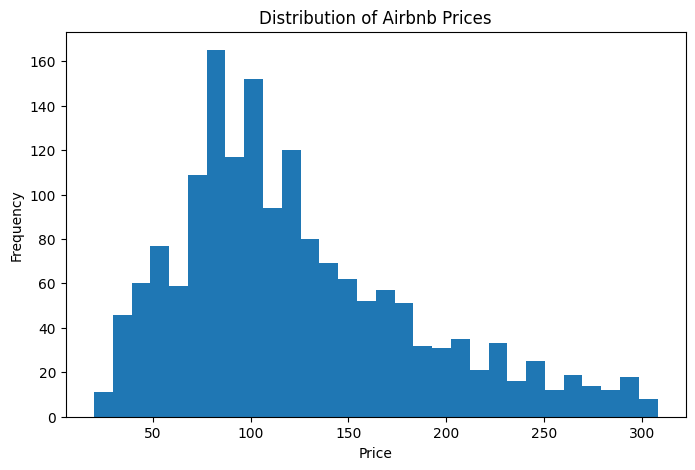

In [11]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=30)
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

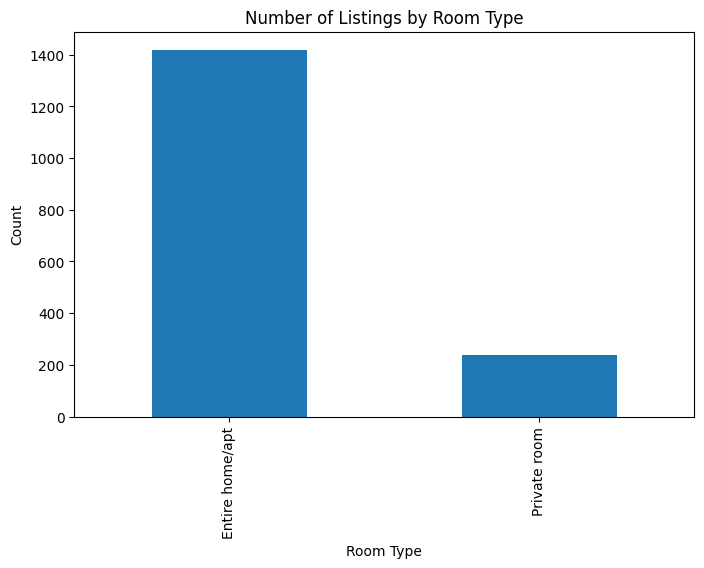

In [16]:
room_counts = df['room_type'].value_counts()

plt.figure(figsize=(8,5))

room_counts.plot(kind='bar')

plt.title("Number of Listings by Room Type")
plt.xlabel("Room Type")
plt.ylabel("Count")

plt.show()

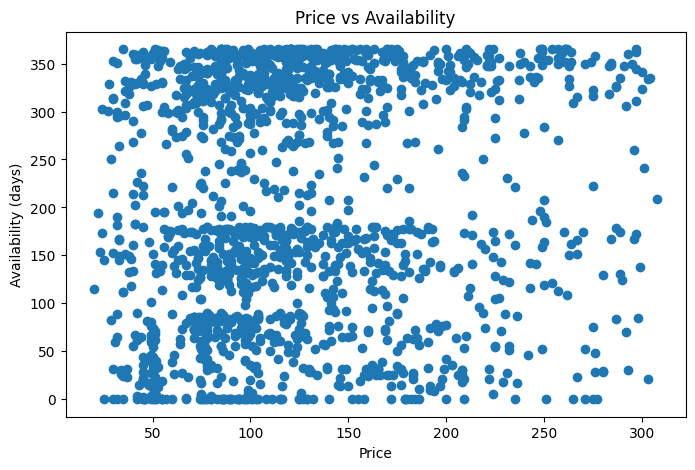

In [17]:
plt.figure(figsize=(8,5))
plt.scatter(df['price'], df['availability_365'])
plt.title("Price vs Availability")
plt.xlabel("Price")
plt.ylabel("Availability (days)")
plt.show()

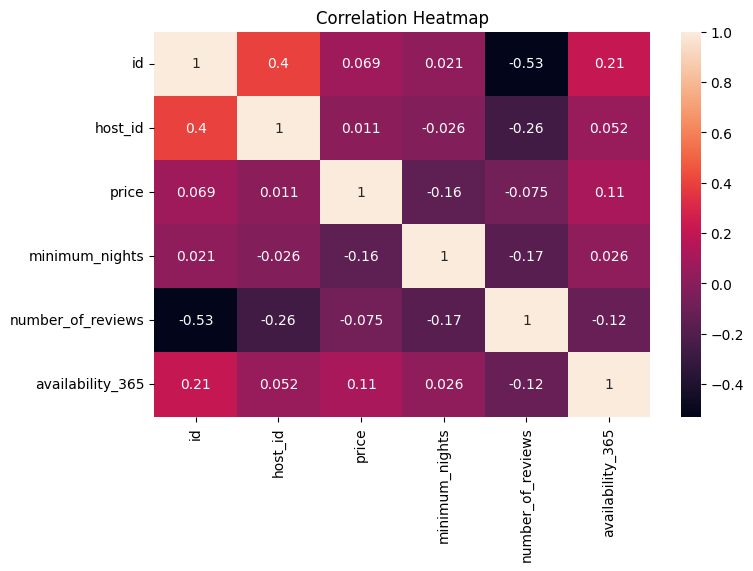

In [18]:
plt.figure(figsize=(8,5))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()